In [14]:
import os
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from safetensors.torch import load_file
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from model import ContextEncoder, IJEPA
from masking import IJEPAMaskSampler
from mae_encoder import load_pretrained_mae_encoder

import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

### WHERE EVERYTHING LIVES ###
PATH_TO_DATA = "/mnt/datadrive/data/ImageNet"
PATH_TO_EXPERIMENT = os.path.join("work_dir", "ijepa_vitb")
FINAL_CHECKPOINT = os.path.join(PATH_TO_EXPERIMENT, "final_checkpoint", "model.safetensors")

### MAE PRETRAINED CHECKPOINT (800 epochs, from the Masked AutoEncoder tutorial in this repo) ###
PATH_TO_MAE_CHECKPOINT = os.path.join("..", "Masked AutoEncoder", "work_dir",
                                      "MAEPretraining", "checkpoint_800", "model.safetensors")

### EVERY FIGURE IN THIS NOTEBOOK IS ALSO WRITTEN HERE AS A PNG ###
SAVE_DIR = "probe_results"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_fig(fig, filename):
    """Save a figure into SAVE_DIR and show it inline"""
    path = os.path.join(SAVE_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

### EVALUATION SUBSET SIZE (100 classes keeps every experiment in this notebook to a few seconds) ###
NUM_EVAL_CLASSES = 100
TRAIN_IMAGES_PER_CLASS = 100    # labelled "memory bank" for kNN / training set for the linear probe
VAL_IMAGES_PER_CLASS = 50       # held out evaluation set (all 50 official val images per class)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")
print("I-JEPA checkpoint found:", os.path.exists(FINAL_CHECKPOINT))
print("MAE checkpoint found:   ", os.path.exists(PATH_TO_MAE_CHECKPOINT))

Device: cuda NVIDIA RTX A6000
I-JEPA checkpoint found: True
MAE checkpoint found:    True


### Pulling encoders out of the pretraining checkpoint

In [15]:
def load_state(path_to_checkpoint):
    """Load the raw state dict of a pretraining checkpoint"""
    return load_file(path_to_checkpoint)

def split_prefix(state_dict, prefix):
    """Grab the weights of one submodule (context_encoder / target_encoder / predictor)"""
    return {k[len(prefix) + 1:]: v for k, v in state_dict.items() if k.startswith(prefix + ".")}

def build_encoder(state_dict=None, which="target_encoder", device=DEVICE):
    """
    Build a ViT encoder. If state_dict is None we get a randomly initialized encoder,
    which is the control condition for every experiment in this notebook.
    """
    encoder = ContextEncoder(img_size=224, patch_size=16, embed_dim=768, depth=12, num_heads=12)
    if state_dict is not None:
        encoder.load_state_dict(split_prefix(state_dict, which), strict=True)
    return encoder.to(device).eval()

state_dict = load_state(FINAL_CHECKPOINT)
print(f"{len(state_dict)} tensors in checkpoint")
print("Submodules:", sorted({k.split(".")[0] for k in state_dict}))

target_encoder = build_encoder(state_dict, "target_encoder")
context_encoder = build_encoder(state_dict, "context_encoder")
random_encoder = build_encoder(None)

print(f"\nEncoder parameters: {sum(p.numel() for p in target_encoder.parameters())/1e6:.1f}M")

378 tensors in checkpoint
Submodules: ['context_encoder', 'predictor', 'target_encoder']

Encoder parameters: 85.8M


### Bringing in MAE as a second point of comparison

Random init tells us whether pretraining did *anything*. A second pretrained model tells us whether **this particular pretext task** was a good idea, so we also load the [Masked AutoEncoder](../Masked%20AutoEncoder) pretrained in this repo. Both models are ViT-B/16 trained on ImageNet-1K without labels, so the comparison is close to apples to apples, and the one thing that really differs is *what the model is asked to predict*:

In [16]:
### Load the pretrained MAE encoder (see mae_encoder.py, it is the MAE tutorial's encoder, trimmed) ###
mae_encoder = load_pretrained_mae_encoder(PATH_TO_MAE_CHECKPOINT, device=DEVICE)

print(f"MAE encoder parameters: {sum(p.numel() for p in mae_encoder.parameters())/1e6:.1f}M")
print("Output tokens per image:", mae_encoder(torch.zeros(1, 3, 224, 224, device=DEVICE)).shape[1],
      "(CLS token dropped so MAE and I-JEPA are pooled identically)")

MAE encoder parameters: 85.8M
Output tokens per image: 196 (CLS token dropped so MAE and I-JEPA are pooled identically)


## Evaluation Data and Feature Extraction

Everything that follows needs features. The setup:

* **100 ImageNet classes** drawn at random with a fixed seed, so every experiment below uses exactly the same subset.
* **train split, 100 images/class = 10,000 images**: labelled memory bank for $k$-NN and training set for the linear probe.
* **val split, 50 images/class = 5,000 images**: held out, never used to fit anything.
* Deterministic eval transform only (resize 256, center crop 224). No augmentation and no masking


In [17]:
### Pick the evaluation classes (fixed seed => identical subset everywhere in this notebook) ###
val_folder = datasets.ImageFolder(os.path.join(PATH_TO_DATA, "validation"))
rng = np.random.default_rng(0)
eval_class_ids = np.sort(rng.choice(len(val_folder.classes), NUM_EVAL_CLASSES, replace=False))
wnids = [val_folder.classes[c] for c in eval_class_ids]

### Human readable names (synset_human.txt maps wnid -> words) ###
synset_to_name = {}
with open(os.path.join(PATH_TO_DATA, "synset_human.txt")) as f:
    for line in f:
        wnid, name = line.strip().split("\t")
        synset_to_name[wnid] = name
class_names = [synset_to_name.get(w, w).split(",")[0] for w in wnids]

print(f"{NUM_EVAL_CLASSES} evaluation classes, for example:")
print(", ".join(class_names[:10]), "...")

100 evaluation classes, for example:
great white shark, electric ray, cock, robin, water ouzel, common newt, tree frog, box turtle, Komodo dragon, sidewinder ...


In [18]:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda im: im.convert("RGB")),
    transforms.PILToTensor(),    # uint8 (3, 224, 224), normalized later on the GPU
])

def preload_split(split, images_per_class, num_workers=32):
    """Decode a class balanced subset once into a single uint8 tensor we keep in RAM"""
    dataset = datasets.ImageFolder(os.path.join(PATH_TO_DATA, split), transform=eval_transform)
    targets = np.array(dataset.targets)

    indices, labels = [], []
    for new_label, class_id in enumerate(eval_class_ids):
        selected = np.where(targets == class_id)[0][:images_per_class]
        indices.extend(selected.tolist())
        labels.extend([new_label] * len(selected))

    loader = DataLoader(Subset(dataset, indices), batch_size=256, shuffle=False, num_workers=num_workers)
    images = torch.cat([x for x, _ in loader])
    return images, torch.tensor(labels)

start = time.time()
train_images, train_labels = preload_split("train", TRAIN_IMAGES_PER_CLASS)
val_images, val_labels = preload_split("validation", VAL_IMAGES_PER_CLASS)
print(f"train: {tuple(train_images.shape)}   val: {tuple(val_images.shape)}   ({time.time()-start:.1f}s)")

train: (10000, 3, 224, 224)   val: (5000, 3, 224, 224)   (9.5s)


### Extract Features for All Images

In [19]:
MEAN_GPU, STD_GPU = IMAGENET_MEAN.to(DEVICE), IMAGENET_STD.to(DEVICE)

def to_model_input(batch):
    x = batch.to(DEVICE, non_blocking=True).float().div_(255.0) # scale from 0-255 -> 0-1
    return (x - MEAN_GPU) / STD_GPU

@torch.no_grad()
def extract_features(encoder, images, batch_size=256):
    """
    Mean pool the final layer patch tokens into one vector per image.
    """
    feats = []
    for i in range(0, len(images), batch_size):
        x = to_model_input(images[i:i + batch_size])
        with torch.autocast(DEVICE, DTYPE, enabled=(DEVICE == "cuda")):
            tokens = encoder(x)                    # (B, 196, 768)
        feats.append(tokens.float().mean(1).cpu())
    return torch.cat(feats)

@torch.no_grad()
def extract_features_all_layers(encoder, images, batch_size=256):
    """
    Same, but returns the pooled embedding after EVERY block from one forward pass
    """
    per_layer = [[] for _ in range(len(encoder.blocks))]
    for i in range(0, len(images), batch_size):
        x = to_model_input(images[i:i + batch_size])
        with torch.autocast(DEVICE, DTYPE, enabled=(DEVICE == "cuda")):
            tokens = encoder.patch_embed(x) + encoder.pos_embed
            for depth, block in enumerate(encoder.blocks):
                tokens = block(tokens)
                per_layer[depth].append(tokens.float().mean(1).cpu())
    return torch.stack([torch.cat(layer) for layer in per_layer])

encoders = {
    "I-JEPA (target)": target_encoder,
    "I-JEPA (context)": context_encoder,
    "MAE (800 epochs)": mae_encoder,
    "Random init": random_encoder,
}

### The three models we put side by side in every figure (context encoder is basically the ###
### same as the target encoder, so it would just be a duplicate panel)                      ###
PLOT_ENCODERS = ["I-JEPA (target)", "MAE (800 epochs)", "Random init"]

start = time.time()
features = {}
for name, encoder in encoders.items():
    features[name] = (extract_features(encoder, train_images), extract_features(encoder, val_images))

print(f"Extracted features for {len(encoders)} encoders x {len(train_images)+len(val_images):,} images "
      f"in {time.time()-start:.1f}s")
print("Feature shape:", tuple(features["I-JEPA (target)"][1].shape))

Extracted features for 4 encoders x 15,000 images in 36.2s
Feature shape: (5000, 768)


## $k$-NN Classification on Frozen Features

We L2-norm the 10K labelled training embeddings, and for each of the 5k held out val embeddings, take the $k=20$ most similar embeddings and vote, weighted by each neighbor by $\exp(\text{cosine}/T)$ with $T=0.07$ (which comes from section F.1 in the [DINO](https://arxiv.org/pdf/2104.14294) paper)

Because no classifier is fit, this measures the geometry of the embedding space directly: are semantically similar images actually close together?

In [20]:
@torch.no_grad()
def knn_classifier(train_feats, train_labels, val_feats, val_labels,
                   k=20, temperature=0.07, num_classes=NUM_EVAL_CLASSES, chunk=512):
    """Cosine similarity weighted kNN classifier returns top1, top5 and predictions"""
    bank = F.normalize(train_feats, dim=1).to(DEVICE)
    queries = F.normalize(val_feats, dim=1).to(DEVICE)
    bank_labels = train_labels.to(DEVICE)

    all_scores = []
    for i in range(0, len(queries), chunk):
        sim = queries[i:i + chunk] @ bank.T                       # (chunk, num_train)
        top_sim, top_idx = sim.topk(k, dim=1)
        weights = (top_sim / temperature).exp()

        scores = torch.zeros(len(top_sim), num_classes, device=DEVICE)
        scores.scatter_add_(1, bank_labels[top_idx], weights)      # vote per class
        all_scores.append(scores.cpu())

    scores = torch.cat(all_scores)
    top5 = scores.topk(5, dim=1).indices
    correct1 = (top5[:, 0] == val_labels).float()
    correct5 = (top5 == val_labels[:, None]).any(1).float()
    return correct1.mean().item(), correct5.mean().item(), top5[:, 0]

knn_results = {}
for name, (train_feats, val_feats) in features.items():
    top1, top5, preds = knn_classifier(train_feats, train_labels, val_feats, val_labels)
    knn_results[name] = (top1, top5, preds)
    print(f"{name:<20} kNN top-1: {top1*100:6.2f}%    top-5: {top5*100:6.2f}%")


I-JEPA (target)      kNN top-1:  69.98%    top-5:  87.06%
I-JEPA (context)     kNN top-1:  68.72%    top-5:  85.96%
MAE (800 epochs)     kNN top-1:  50.66%    top-5:  73.82%
Random init          kNN top-1:   6.08%    top-5:  18.00%


## Linear Probe

The standard self-supervised benchmark: freeze the backbone, fit a **single linear layer** on the frozen features. If a linear boundary separates the classes, the representation has already done the hard nonlinear work of turning pixels into semantics.

In [21]:
def linear_probe(train_feats, train_labels, val_feats, val_labels,
                 num_classes=NUM_EVAL_CLASSES, epochs=100, lr=1e-3, weight_decay=1e-4, batch_size=1024):
    """Fit a linear classifier on frozen features, return top1 / top5 on the held out set"""
    mean, std = train_feats.mean(0, keepdim=True), train_feats.std(0, keepdim=True) + 1e-6
    Xtr = ((train_feats - mean) / std).to(DEVICE)
    Xva = ((val_feats - mean) / std).to(DEVICE)
    ytr, yva = train_labels.to(DEVICE), val_labels.to(DEVICE)

    probe = nn.Linear(Xtr.shape[1], num_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        perm = torch.randperm(len(Xtr), device=DEVICE)
        for i in range(0, len(perm), batch_size):
            idx = perm[i:i + batch_size]
            loss = loss_fn(probe(Xtr[idx]), ytr[idx])
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        scheduler.step()

    with torch.no_grad():
        logits = probe(Xva)
        top5 = logits.topk(5, dim=1).indices
        top1_acc = (top5[:, 0] == yva).float().mean().item()
        top5_acc = (top5 == yva[:, None]).any(1).float().mean().item()
    return top1_acc, top5_acc

probe_results = {}
for name, (train_feats, val_feats) in features.items():
    start = time.time()
    top1, top5 = linear_probe(train_feats, train_labels, val_feats, val_labels)
    probe_results[name] = (top1, top5)
    print(f"{name:<20} linear probe top-1: {top1*100:6.2f}%    top-5: {top5*100:6.2f}%   ({time.time()-start:.0f}s)")

I-JEPA (target)      linear probe top-1:  77.64%    top-5:  91.92%   (0s)
I-JEPA (context)     linear probe top-1:  76.32%    top-5:  91.24%   (0s)
MAE (800 epochs)     linear probe top-1:  74.92%    top-5:  92.40%   (0s)
Random init          linear probe top-1:  12.84%    top-5:  32.70%   (0s)


### Both probes, all three encoders, one picture

$k$-NN fits nothing and linear probing fits a single matrix, so together they bracket how much semantic structure is sitting in the frozen features.

saved probe_results/frozen_eval_accuracy.png


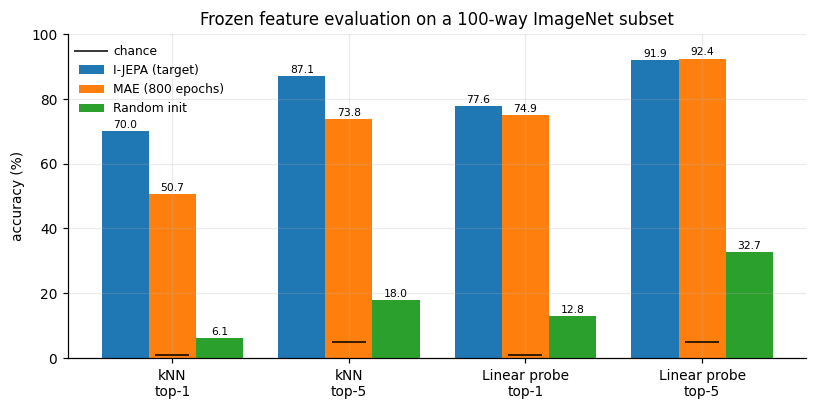

model                 kNN top-1  kNN top-5  linear top-1  linear top-5
I-JEPA (target)          69.98%     87.06%        77.64%        91.92%
MAE (800 epochs)         50.66%     73.82%        74.92%        92.40%
Random init               6.08%     18.00%        12.84%        32.70%


In [22]:
### Grouped bars: kNN and linear probe, every model, against chance ###
metrics = [("kNN\ntop-1", knn_results, 0), ("kNN\ntop-5", knn_results, 1),
           ("Linear probe\ntop-1", probe_results, 0), ("Linear probe\ntop-5", probe_results, 1)]
chance = [100 / NUM_EVAL_CLASSES, 500 / NUM_EVAL_CLASSES] * 2

x = np.arange(len(metrics))
width = 0.8 / len(PLOT_ENCODERS)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for i, name in enumerate(PLOT_ENCODERS):
    values = [results[name][idx] * 100 for _, results, idx in metrics]
    bars = ax.bar(x + i * width - 0.4 + width / 2, values, width, label=name)
    ax.bar_label(bars, fmt="%.1f", fontsize=7, padding=1)

ax.plot(x, chance, "k_", markersize=22, label="chance")
ax.set_xticks(x, [m[0] for m in metrics])
ax.set(ylabel="accuracy (%)", ylim=(0, 100),
       title=f"Frozen feature evaluation on a {NUM_EVAL_CLASSES}-way ImageNet subset")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
save_fig(fig, "frozen_eval_accuracy.png")
plt.show()

print(f"{'model':<20}{'kNN top-1':>11}{'kNN top-5':>11}{'linear top-1':>14}{'linear top-5':>14}")
for name in PLOT_ENCODERS:
    print(f"{name:<20}{knn_results[name][0]*100:>10.2f}%{knn_results[name][1]*100:>10.2f}%"
          f"{probe_results[name][0]*100:>13.2f}%{probe_results[name][1]*100:>13.2f}%")

## What Does the Embedding Space Look Like?

saved probe_results/tsne_comparison.png


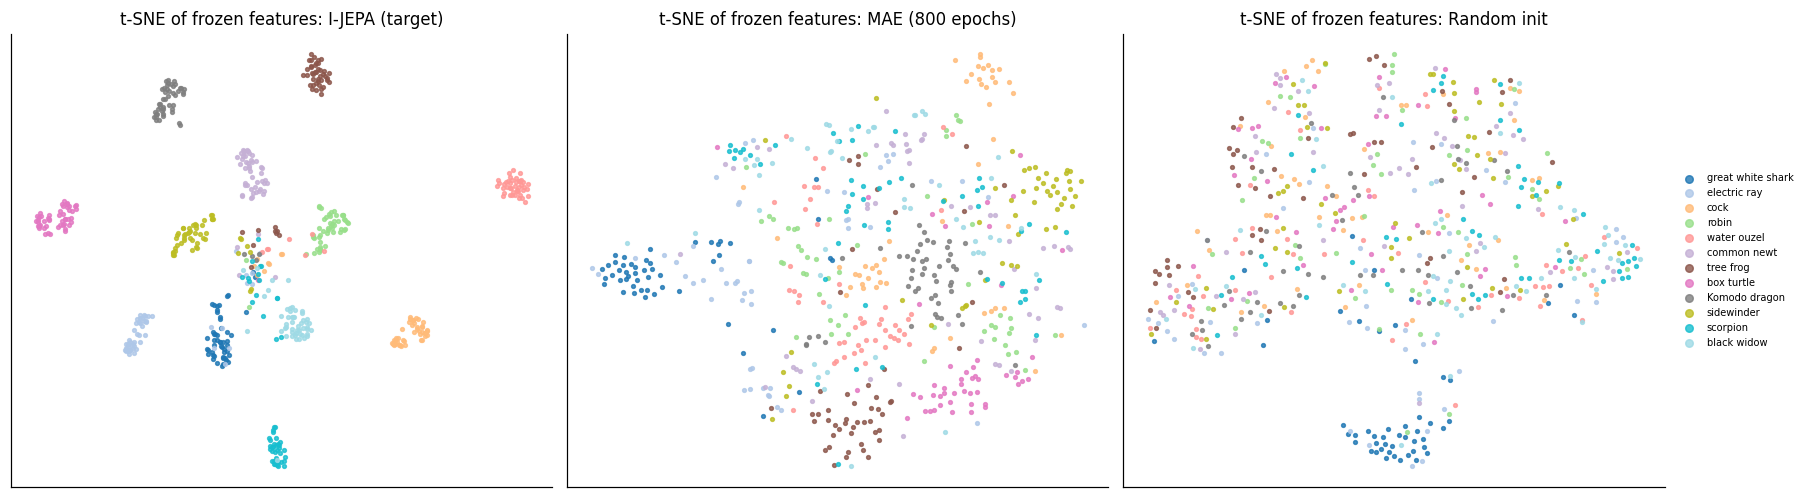

In [23]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

VIS_CLASSES = 12
vis_mask = val_labels < VIS_CLASSES
vis_labels = val_labels[vis_mask].numpy()

fig, axes = plt.subplots(1, len(PLOT_ENCODERS), figsize=(5.5 * len(PLOT_ENCODERS), 4.6))
for ax, name in zip(axes, PLOT_ENCODERS):
    feats = features[name][1][vis_mask].numpy()
    reduced = PCA(n_components=50, random_state=0).fit_transform(feats)
    embedded = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(reduced)
    colors = plt.get_cmap("tab20")(np.linspace(0, 1, VIS_CLASSES))
    for c in range(VIS_CLASSES):
        sel = vis_labels == c
        ax.scatter(embedded[sel, 0], embedded[sel, 1], s=6, alpha=0.8,
                   color=colors[c], label=class_names[c][:18])
    ax.set(title=f"t-SNE of frozen features: {name}", xticks=[], yticks=[])
    ax.grid(alpha=0)
axes[-1].legend(frameon=False, fontsize=6.5, markerscale=2, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
save_fig(fig, "tsne_comparison.png")
plt.show()

### Nearest neighbour retrieval

Even more direct: take a val image, embed it, and pull the closest images from the 10k train bank by cosine similarity. Retrieval quality is the thing $k$-NN accuracy is measuring, but seeing it makes the failure cases legible (are the mistakes semantically reasonable, or random?).

saved probe_results/retrieval_ijepa_target.png


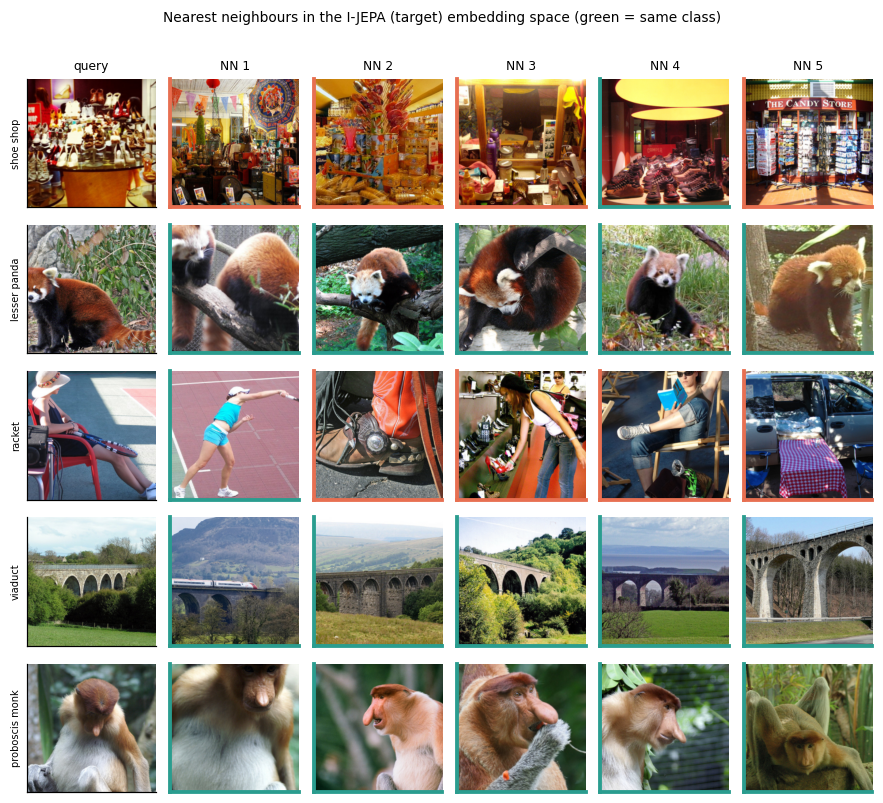

saved probe_results/retrieval_mae_800_epochs.png


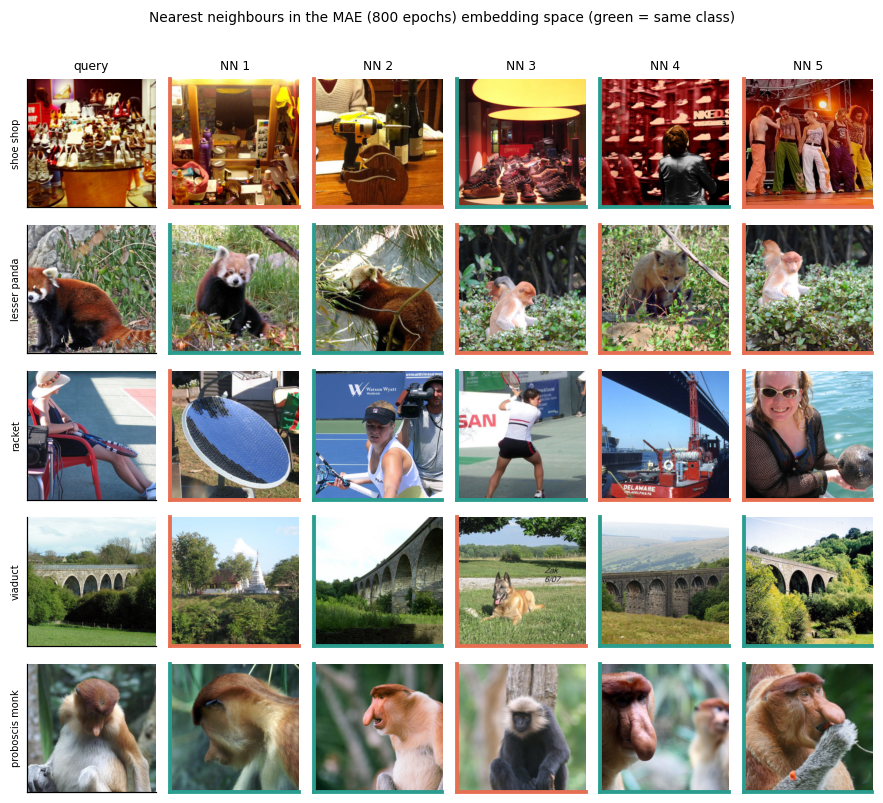

saved probe_results/retrieval_random_init.png


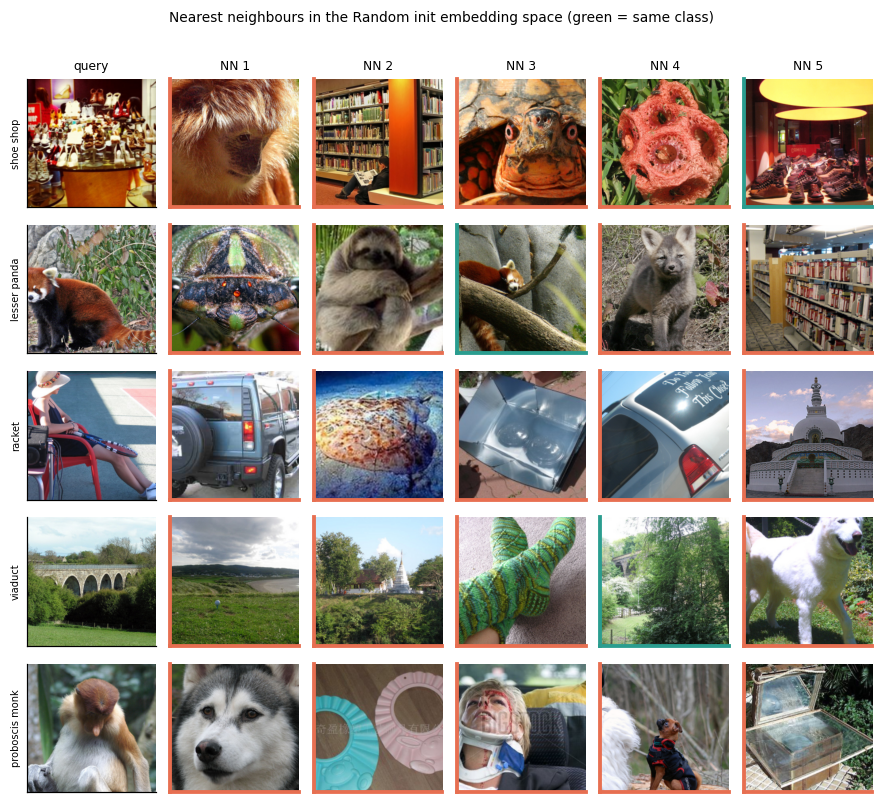

In [24]:
def show_retrievals(feature_name, num_queries=5, num_neighbours=5, seed=3):
    train_feats, val_feats = features[feature_name]
    bank = F.normalize(train_feats, dim=1)
    queries = F.normalize(val_feats, dim=1)

    g = torch.Generator().manual_seed(seed)
    query_ids = torch.randperm(len(queries), generator=g)[:num_queries]
    sims = queries[query_ids] @ bank.T
    neighbours = sims.topk(num_neighbours, dim=1).indices

    fig, axes = plt.subplots(num_queries, num_neighbours + 1,
                             figsize=(1.35 * (num_neighbours + 1), 1.45 * num_queries))
    for row, qid in enumerate(query_ids):
        axes[row, 0].imshow(val_images[qid].permute(1, 2, 0).numpy())
        axes[row, 0].set_ylabel(class_names[val_labels[qid]][:14], fontsize=6.5)
        if row == 0:
            axes[row, 0].set_title("query", fontsize=8)
        for col in range(num_neighbours):
            nid = neighbours[row, col]
            ax = axes[row, col + 1]
            ax.imshow(train_images[nid].permute(1, 2, 0).numpy())
            match = train_labels[nid] == val_labels[qid]
            for spine in ax.spines.values():
                spine.set_color("#2a9d8f" if match else "#e76f51")
                spine.set_linewidth(2.5)
            if row == 0:
                ax.set_title(f"NN {col+1}", fontsize=8)
        for ax in axes[row]:
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0)
    matches = sum(int(train_labels[neighbours[r, c]] == val_labels[query_ids[r]])
                  for r in range(num_queries) for c in range(num_neighbours))
    precision = matches / (num_queries * num_neighbours)

    fig.suptitle(f"Nearest neighbours in the {feature_name} embedding space "
                 f"(green = same class)", y=1.005, fontsize=9)
    plt.tight_layout()
    slug = feature_name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "")
    save_fig(fig, f"retrieval_{slug}.png")
    plt.show()

for name in PLOT_ENCODERS:
    show_retrievals(name)